In [166]:
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Read CSV File

In [73]:
df = pd.read_csv('data/cleaned_data.csv')

In [74]:
df.head()


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


Profitability Metric Calculation

In [75]:
#profit per unit
df['profit_per_unit'] = df['gross_profit'] / df['units']

In [76]:
# Profit Contribution
total_profit = df['gross_profit'].sum()

df['Total Profit Contribution %'] = (
    df['gross_profit'] / total_profit
) * 100

In [77]:
# Revenue Contribution
total_sales = df['sales'].sum()

df['Revenue Contribution %'] = (
                                       df['sales'] / total_sales
                               ) * 100

In [ ]:
# Gross Margin
df['gross_margin %'] = (df['gross_profit'] / df['sales']) * 100

In [78]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,...,region,product_id,product_name,sales,units,gross_profit,cost,profit_per_unit,Total Profit Contribution %,Revenue Contribution %
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2.11,0.004516,0.004584
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2.45,0.005244,0.005290
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2.49,0.007994,0.007384
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2.50,0.008026,0.007617
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2.45,0.007866,0.007935


Margin Volitility

In [79]:
#convert date time at dd-mm-yyy format
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True
)

In [80]:
# convert into datetime at yyy-mm-dd format
#df['order_date'] = pd.to_datetime(df['order_date'])


In [81]:
#check datatype
print(df['order_date'].dtype)


datetime64[us]


In [82]:
#create month column
df['Month'] = df['order_date'].dt.to_period('M')

In [83]:
df.columns


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost', 'profit_per_unit',
       'Total Profit Contribution %', 'Revenue Contribution %', 'Month'],
      dtype='str')

In [84]:
# Check result
print(df[['order_date', 'Month']].head())

  order_date    Month
0 2024-01-03  2024-01
1 2024-01-04  2024-01
2 2024-01-04  2024-01
3 2024-01-04  2024-01
4 2024-01-05  2024-01


In [85]:
# Gross Margin
df['gross_margin %'] = (df['gross_profit'] / df['sales']) * 100

In [86]:
#Monthly Margin
monthly_margin = df.groupby(
    ['product_name', 'Month']
)['gross_margin %'].mean().reset_index()

In [87]:
#Volatility
margin_volatility = monthly_margin.groupby(
    'product_name'
)['gross_margin %'].std().reset_index()

In [88]:
#Rename column
margin_volatility.columns = [
    'product_name',
    'margin_volatility'
]

In [89]:
#Merge Back
df = df.merge(
    margin_volatility,
    on='product_name',
    how='left'
)

In [90]:
df['gross_margin %'] = df['gross_margin %'].round(2)
df['margin_volatility'] = df['margin_volatility'].round(2)
df['profit_per_unit']=df['profit_per_unit'].round(2)

In [91]:
df['Total Profit Contribution %']=df['Total Profit Contribution %'].round(2)
df['Revenue Contribution %']=df['Revenue Contribution %'].round(2)

Product-Level Profitability Analysis

In [92]:
product_analysis = df.groupby('product_name').agg({
    'sales': 'sum',
    'gross_profit': 'sum',
    'gross_margin %': 'mean',
    'units': 'sum'
}).reset_index()

Rank Products by Gross Profit

In [93]:
top_profit_products = product_analysis.sort_values(
    by='gross_profit',
    ascending=False
)
top_profit_products.head(10)

,product_name,sales,gross_profit,gross_margin %,units
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,7743
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,7596
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,8267
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,6755
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,6914
6,Lickable Wallpaper,7860.00,3930.00,50.00,393
14,Wonka Gum,597.50,310.70,52.00,478
0,Everlasting Gobstopper,130.00,104.00,80.00,13
4,Kazookles,1205.75,92.75,7.69,371
3,Hair Toffee,76.50,59.50,77.78,17


Rank Products by Gross Margin

In [94]:
top_margin_products = product_analysis.sort_values(
    by='gross_margin %',
    ascending=False
)
top_margin_products.head(10)

,product_name,sales,gross_profit,gross_margin %,units
0,Everlasting Gobstopper,130.00,104.00,80.00,13
3,Hair Toffee,76.50,59.50,77.78,17
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,6755
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,7743
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,6914
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,7596
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,8267
5,Laffy Taffy,53.73,33.48,62.31,27
1,Fizzy Lifting Drinks,78.75,47.25,60.00,21
14,Wonka Gum,597.50,310.70,52.00,478


High - Profit / High - Margin Products

In [95]:
avg_profit = product_analysis['gross_profit'].mean()
avg_margin = product_analysis['gross_margin %'].mean()

high_profit_high_margin = product_analysis[
    (product_analysis['gross_profit'] > avg_profit) &
    (product_analysis['gross_margin %'] > avg_margin)
    ]
high_profit_high_margin

,product_name,sales,gross_profit,gross_margin %,units
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,6914
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,8267
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,6755
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,7596
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,7743


High - Sales / Low - Margin Products

In [96]:
avg_sales = product_analysis['sales'].mean()

high_sales_low_margin = product_analysis[
    (product_analysis['sales'] > avg_sales) &
    (product_analysis['gross_margin %'] < avg_margin)
    ]
high_sales_low_margin

,product_name,sales,gross_profit,gross_margin %,units


Low - Sales / Low - Profit Products

In [97]:
low_sales_low_profit = product_analysis[
    (product_analysis['sales'] < avg_sales) &
    (product_analysis['gross_profit'] < avg_profit)
    ]
low_sales_low_profit

,product_name,sales,gross_profit,gross_margin %,units
0,Everlasting Gobstopper,130.00,104.00,80.00,13
1,Fizzy Lifting Drinks,78.75,47.25,60.00,21
2,Fun Dip,12.00,4.80,40.00,8
3,Hair Toffee,76.50,59.50,77.78,17
4,Kazookles,1205.75,92.75,7.69,371
5,Laffy Taffy,53.73,33.48,62.31,27
6,Lickable Wallpaper,7860.00,3930.00,50.00,393
7,Nerds,15.00,7.00,46.67,10
8,SweeTARTS,61.50,28.70,46.67,41
14,Wonka Gum,597.50,310.70,52.00,478


In [98]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,...,sales,units,gross_profit,cost,profit_per_unit,Total Profit Contribution %,Revenue Contribution %,Month,gross_margin %,margin_volatility
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,6.50,2,4.22,2.28,2.11,0.00,0.00,2024-01,64.92,0.0
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,2,4.90,2.60,2.45,0.01,0.01,2024-01,65.33,0.0
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,10.47,3,7.47,3.00,2.49,0.01,0.01,2024-01,71.35,0.0
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,10.80,3,7.50,3.30,2.50,0.01,0.01,2024-01,69.44,0.0
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,11.25,3,7.35,3.90,2.45,0.01,0.01,2024-01,65.33,0.0


Division-Level Performance Analysis

In [99]:
division_analysis = df.groupby('division').agg({
    'sales': 'sum',
    'gross_profit': 'sum',
    'gross_margin %': 'mean',
    'units': 'sum'
}).reset_index()

In [100]:
division_analysis

,division,sales,gross_profit,gross_margin %,units
0,Chocolate,131692.90,88824.62,67.457102,37275
1,Other,9663.25,4333.45,37.671742,1242
2,Sugar,427.48,284.73,57.690000,137


Average margin by division

In [101]:
#Rank Divisions by Margin
division_analysis.sort_values(
    by='gross_margin %',
    ascending=False
)

,division,sales,gross_profit,gross_margin %,units
0,Chocolate,131692.90,88824.62,67.457102,37275
2,Sugar,427.48,284.73,57.690000,137
1,Other,9663.25,4333.45,37.671742,1242


In [102]:
#Revenue vs Profit Imbalance
#Create Profit-to-Sales Ratio
division_analysis['profit_ratio %'] = (
    division_analysis['gross_profit']
    / division_analysis['sales']
) * 100

In [103]:
#Calculate Benchmarks
avg_div_profit = division_analysis['gross_profit'].mean()

avg_div_margin = division_analysis[
    'gross_margin %'
].mean()

In [104]:
#Strong Division
strong_divisions = division_analysis[
    (division_analysis['gross_profit'] > avg_div_profit) &
    (division_analysis['gross_margin %'] > avg_div_margin)
]
strong_divisions

,division,sales,gross_profit,gross_margin %,units,profit_ratio %
0,Chocolate,131692.9,88824.62,67.457102,37275,67.448298


In [105]:
#Margin-Issue Divisions
margin_issue_divisions = division_analysis[
    (division_analysis['sales']
     > division_analysis['sales'].mean()) &

    (division_analysis['gross_margin %']
     < avg_div_margin)
]

margin_issue_divisions

,division,sales,gross_profit,gross_margin %,units,profit_ratio %


In [106]:
#Create Division Performance Category
def division_performance(row):

    if (
        row['gross_profit'] > avg_div_profit and
        row['gross_margin %'] > avg_div_margin
    ):
        return 'Strong Financial Efficiency'

    elif (
        row['sales'] > division_analysis['sales'].mean() and
        row['gross_margin %'] < avg_div_margin
    ):
        return 'Structural Margin Issue'

    else:
        return 'Moderate Performance'


division_analysis['division_performance'] = (
    division_analysis.apply(
        division_performance,
        axis=1
    )
)

In [107]:
#Final Output
division_analysis

,division,sales,gross_profit,gross_margin %,units,profit_ratio %,division_performance
0,Chocolate,131692.90,88824.62,67.457102,37275,67.448298,Strong Financial Efficiency
1,Other,9663.25,4333.45,37.671742,1242,44.844643,Moderate Performance
2,Sugar,427.48,284.73,57.690000,137,66.606625,Moderate Performance


Profit Concentration (Pareto) Analysis

In [108]:
#Product-wise Revenue & Profit
pareto_df = df.groupby('product_name').agg({
    'sales': 'sum',
    'gross_profit': 'sum'
}).reset_index()

In [109]:
#Sort by Revenue
pareto_df = pareto_df.sort_values(
    by='sales',
    ascending=False
)

In [110]:
#Calculate Revenue Contribution %
total_sales = pareto_df['sales'].sum()

pareto_df['revenue_contribution %'] = (
    pareto_df['sales'] / total_sales
) * 100

In [111]:
#Calculate Cumulative Revenue %
pareto_df['cumulative_revenue %'] = (
    pareto_df['revenue_contribution %']
).cumsum()

In [112]:
#Identify Products Driving 80% Revenue
top_80_revenue_products = pareto_df[
    pareto_df['cumulative_revenue %'] <= 80
]
top_80_revenue_products

,product_name,sales,gross_profit,revenue_contribution %,cumulative_revenue %
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,20.090472,20.090472
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,19.660098,39.750569
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,18.949825,58.700394
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,17.555200,76.255595


In [113]:
#Profit Pareto Analysis
#Sort by Profit
profit_pareto = pareto_df.sort_values(
    by='gross_profit',
    ascending=False
)

In [114]:
#Profit Contribution %
total_profit = profit_pareto['gross_profit'].sum()

profit_pareto['profit_contribution %'] = (
    profit_pareto['gross_profit']
    / total_profit
) * 100

In [115]:
#Cumulative Profit %
profit_pareto['cumulative_profit %'] = (
    profit_pareto['profit_contribution %']
).cumsum()

In [116]:
#Products Driving 80% Profit
top_80_profit_products = profit_pareto[
    profit_pareto['cumulative_profit %'] <= 80
]
top_80_profit_products

,product_name,sales,gross_profit,revenue_contribution %,cumulative_revenue %,profit_contribution %,cumulative_profit %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,19.660098,39.750569,20.715882,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,20.090472,20.090472,19.916141,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,18.949825,58.700394,18.667431,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,16.627413,92.883008,18.000263,77.299717


#Detect Over-Dependency Risk

In [117]:
#Count Top Products
num_top_products = len(top_80_profit_products)

total_products = df['product_name'].nunique()

dependency_ratio = (
    num_top_products / total_products
) * 100

print(dependency_ratio)

26.666666666666668


Detect Congestion-Prone States/Regions

In [118]:
#State-wise Revenue
state_sales = df.groupby('state/province').agg({
    'sales': 'sum',
    'gross_profit': 'sum'
}).reset_index()

In [119]:
#Sort by Sales
state_sales = state_sales.sort_values(
    by='sales',
    ascending=False
)

In [120]:
#Revenue Contribution %
total_state_sales = state_sales['sales'].sum()

state_sales['revenue_contribution %'] = (
    state_sales['sales']
    / total_state_sales
) * 100

In [121]:
#Cumulative Contribution
state_sales['cumulative_revenue %'] = (
    state_sales['revenue_contribution %']
).cumsum()

Identify High Dependency States

In [122]:
high_dependency_states = state_sales[
    state_sales['cumulative_revenue %'] <= 80
]
high_dependency_states

,state/province,sales,gross_profit,revenue_contribution %,cumulative_revenue %
5,California,27917.40,18479.42,19.690143,19.690143
34,New York,15541.03,10222.44,10.961089,30.651232
51,Texas,13416.09,8909.53,9.462369,40.113601
43,Pennsylvania,8027.03,5225.47,5.661465,45.775066
55,Washington,6921.15,4566.64,4.881487,50.656553
13,Illinois,6898.96,4557.68,4.865837,55.522390
39,Ohio,6768.95,4413.03,4.774141,60.296531
10,Florida,4804.02,3207.11,3.388276,63.684806
2,Arizona,3587.55,2290.11,2.530299,66.215105
36,North Carolina,3450.86,2331.16,2.433892,68.648997


SQL Connection

In [123]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,...,sales,units,gross_profit,cost,profit_per_unit,Total Profit Contribution %,Revenue Contribution %,Month,gross_margin %,margin_volatility
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,6.50,2,4.22,2.28,2.11,0.00,0.00,2024-01,64.92,0.0
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,2,4.90,2.60,2.45,0.01,0.01,2024-01,65.33,0.0
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,10.47,3,7.47,3.00,2.49,0.01,0.01,2024-01,71.35,0.0
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,10.80,3,7.50,3.30,2.50,0.01,0.01,2024-01,69.44,0.0
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,11.25,3,7.35,3.90,2.45,0.01,0.01,2024-01,65.33,0.0


Cost Structure Diagnostics

In [124]:
#Create Cost Efficiency KPI
df['cost_efficiency_ratio %'] = (
    df['cost'] / df['sales']
) * 100

In [160]:
#cost_efficiency_ratio % round 2 digit
df['cost_efficiency_ratio %'] = (
    df['cost_efficiency_ratio %']
    .round(2)
)

In [ ]:
#cost_efficiency_ratio % round 2 digit
df['cost_efficiency_ratio %'] = (
    df['cost_efficiency_ratio %']
    .round(2)
    .astype(int)
)

In [125]:
#Product-wise Cost Analysis
cost_analysis = df.groupby('product_name').agg({
    'sales': 'sum',
    'cost': 'sum',
    'gross_profit': 'sum',
    'gross_margin %': 'mean',
    'cost_efficiency_ratio %': 'mean'
}).reset_index()

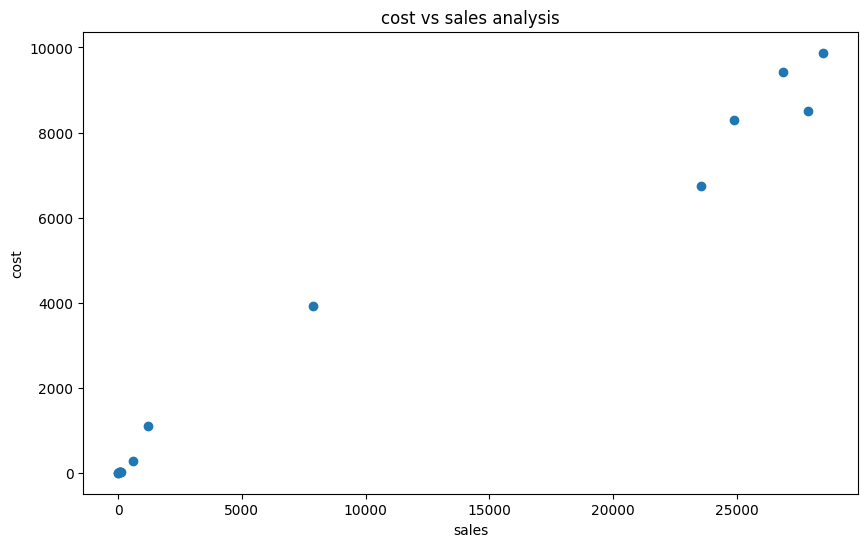

In [126]:
#Cost vs Sales Scatter Analysis
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    cost_analysis['sales'],
    cost_analysis['cost']
)

plt.xlabel('sales')
plt.ylabel('cost')

plt.title('cost vs sales analysis')

plt.show()

In [127]:
#Benchmarks
avg_cost_ratio = cost_analysis[
    'cost_efficiency_ratio %'
].mean()

avg_margin = cost_analysis[
    'gross_margin %'
].mean()

In [128]:
#filter products
cost_heavy_margin_poor = cost_analysis[
    (cost_analysis['cost_efficiency_ratio %']
     > avg_cost_ratio) &

    (cost_analysis['gross_margin %']
     < avg_margin)
]

cost_heavy_margin_poor

,product_name,sales,cost,gross_profit,gross_margin %,cost_efficiency_ratio %
2,Fun Dip,12.00,7.2,4.80,40.00,60.000000
4,Kazookles,1205.75,1113.0,92.75,7.69,92.307692
6,Lickable Wallpaper,7860.00,3930.0,3930.00,50.00,50.000000
7,Nerds,15.00,8.0,7.00,46.67,53.333333
8,SweeTARTS,61.50,32.8,28.70,46.67,53.333333
14,Wonka Gum,597.50,286.8,310.70,52.00,48.000000


In [129]:
#Identify Pricing Inefficiencies
avg_sales = cost_analysis['sales'].mean()

pricing_inefficiencies = cost_analysis[
    (cost_analysis['sales'] > avg_sales) &

    (cost_analysis['gross_margin %']
     < avg_margin)
]

pricing_inefficiencies

,product_name,sales,cost,gross_profit,gross_margin %,cost_efficiency_ratio %


In [142]:
#Create Action Recommendation KPI
def recommendation(row):

    if (
        row['cost_efficiency_ratio %']
        > avg_cost_ratio
        and
        row['gross_margin %']
        < avg_margin
    ):
        return 'Cost Renegotiation Needed'

    elif (
        row['sales'] > avg_sales
        and
        row['gross_margin %']
        < avg_margin
    ):
        return 'Repricing Required'

    elif (
        row['sales'] < avg_sales
        and
        row['gross_profit']
        < cost_analysis['gross_profit'].mean()
    ):
        return 'Discontinuation Review'

    else:
        return 'Healthy Product'

    # Add new column into dataframe
cost_analysis['business_recommendation'] = (
    cost_analysis.apply(
        recommendation,
        axis=1
    )
)

In [150]:
#Merge Into Main DataFrame
df = df.merge(
    cost_analysis[
        ['product_name', 'business_recommendation']
    ],
    on='product_name',
    how='left'
)

In [151]:
#verify
df[
    [
        'product_name',
        'business_recommendation'
    ]
].head()


,product_name,business_recommendation
0,Wonka Bar - Milk Chocolate,Healthy Product
1,Wonka Bar - Triple Dazzle Caramel,Healthy Product
2,Wonka Bar - Nutty Crunch Surprise,Healthy Product
3,Wonka Bar -Scrumdiddlyumptious,Healthy Product
4,Wonka Bar - Triple Dazzle Caramel,Healthy Product


In [143]:
#Final Output
cost_analysis.head()


,product_name,sales,cost,gross_profit,gross_margin %,cost_efficiency_ratio %,business_recommendation
0,Everlasting Gobstopper,130.00,26.0,104.00,80.00,20.000000,Discontinuation Review
1,Fizzy Lifting Drinks,78.75,31.5,47.25,60.00,40.000000,Discontinuation Review
2,Fun Dip,12.00,7.2,4.80,40.00,60.000000,Cost Renegotiation Needed
3,Hair Toffee,76.50,17.0,59.50,77.78,22.222222,Discontinuation Review
4,Kazookles,1205.75,1113.0,92.75,7.69,92.307692,Cost Renegotiation Needed


In [132]:
#Convert Month Column to String
df['Month'] = df['Month'].astype(str)

In [146]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country/region', 'city', 'state/province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost', 'profit_per_unit',
       'Total Profit Contribution %', 'Revenue Contribution %', 'Month',
       'gross_margin %', 'margin_volatility', 'cost_efficiency_ratio %',
       'margin_risk'],
      dtype='str')

In [147]:
df.head()


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,...,gross_profit,cost,profit_per_unit,Total Profit Contribution %,Revenue Contribution %,Month,gross_margin %,margin_volatility,cost_efficiency_ratio %,margin_risk
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,4.22,2.28,2.11,0.00,0.00,2024-01,64.92,0.0,35.076923,Low Risk
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,4.90,2.60,2.45,0.01,0.01,2024-01,65.33,0.0,34.666667,Low Risk
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.47,3.00,2.49,0.01,0.01,2024-01,71.35,0.0,28.653295,Low Risk
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,3.30,2.50,0.01,0.01,2024-01,69.44,0.0,30.555556,Low Risk
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,7.35,3.90,2.45,0.01,0.01,2024-01,65.33,0.0,34.666667,Low Risk


In [135]:
def margin_risk(row):

    if row['gross_margin %'] < 15:
        return 'High Risk'

    elif row['gross_margin %'] < 30:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['margin_risk'] = (
    df.apply(
        margin_risk,
        axis=1
    )
)

In [163]:
#Rename Columns Properly
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('%', 'percent')
)

In [170]:
# final csv file
df.to_csv("final_nassau_data.csv", index=False)

In [137]:
from sqlalchemy import create_engine
# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "pooja" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "Nassau_Canddy_DistributorDB"    # the database you created in pgAdmin
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")


In [165]:
# Step 2: Load DataFrame into PostgreSQL
table_name = "sales_data"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'sales_data' in database 'Nassau_Canddy_DistributorDB'.
